In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,
    classification_report,ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import joblib

In [2]:
train_df = pd.read_csv("../data/processed/train_smote.csv")
test_df = pd.read_csv("../data/processed/test_data.csv")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (1582354, 48)
Test Shape : (200000, 48)


In [3]:
X_train = train_df.drop("fraud_bool", axis=1)
y_train = train_df["fraud_bool"]
X_test = test_df.drop("fraud_bool", axis=1)
y_test = test_df["fraud_bool"]

In [4]:
svm = LinearSVC(random_state=42,max_iter=5000)
svm.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",5000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are su

In [5]:
y_pred = svm.predict(X_test)

In [6]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.93505
Precision: 0.06683804627249357
Recall   : 0.3771532184950136
F1 Score : 0.11355261362085438


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97    197794
           1       0.07      0.38      0.11      2206

    accuracy                           0.94    200000
   macro avg       0.53      0.66      0.54    200000
weighted avg       0.98      0.94      0.96    200000



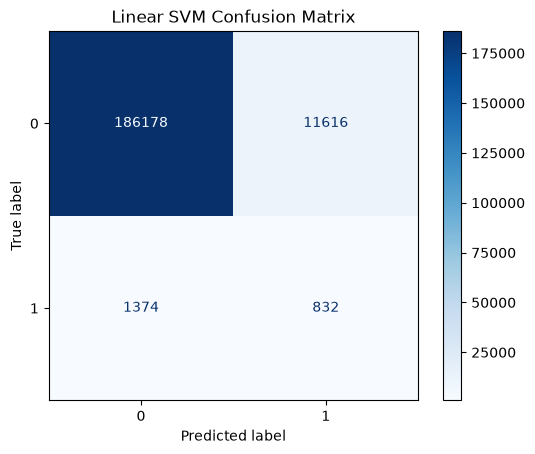

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Linear SVM Confusion Matrix")
plt.show()

In [9]:
importance = pd.DataFrame({"Feature": X_train.columns,"Importance": np.abs(svm.coef_[0])})
importance = importance.sort_values(by="Importance",ascending=False)
importance.head(20)

,Feature,Importance
39,housing_status_4,1.296573
28,payment_type_3,1.171873
18,has_other_cards,1.115241
38,housing_status_3,1.001206
37,housing_status_2,0.976540
36,housing_status_1,0.929672
26,payment_type_1,0.864943
43,device_os_1,0.836398
30,employment_status_1,0.807278
27,payment_type_2,0.780592


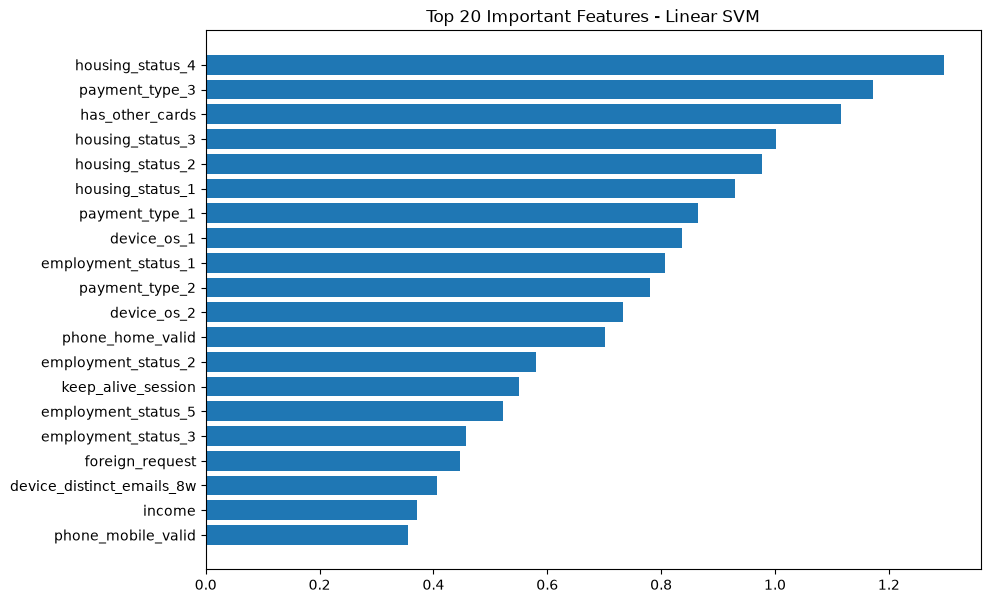

In [10]:
top20 = importance.head(20)
plt.figure(figsize=(10,7))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features - Linear SVM")
plt.show()

In [11]:
importance.to_csv("../data/processed/svm_feature_importance.csv",index=False)
print("Feature importance saved.")

Feature importance saved.


In [12]:
joblib.dump(svm,"../models/svm.pkl")
print("SVM model saved successfully.")

SVM model saved successfully.


## Summary

- Loaded the SMOTE-balanced training dataset and original test dataset.
- Trained a Linear Support Vector Machine (LinearSVC) classifier.
- Evaluated the model using Accuracy, Precision, Recall, and F1-score.
- Generated a Classification Report and Confusion Matrix.
- Calculated feature importance using the absolute values of model coefficients.
- Visualized the top 20 most influential features.
- Saved feature importance and the trained SVM model for future comparison and deployment.